In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Upload the CSV file to Google Colab

from google.colab import files

uploaded = files.upload()

print("Uploaded file(s):", list(uploaded.keys()))


Saving retail_sales.csv to retail_sales.csv
Uploaded file(s): ['retail_sales.csv']


In [3]:
# Load the uploaded dataset

file_name = next(iter(uploaded.keys()))
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
df.head()


Dataset loaded successfully!


,Order_ID,Date,City,Product,Category,Units_Sold,Unit_Price,Discount,Sales,Profit,Payment_Method
0,1,2025-11-24,Pune,Smartphone,Electronics,1,596.62,0.05,566.79,208.02,UPI
1,2,2025-12-13,Bengaluru,Coffee Maker,Home Appliances,1,112.91,0.00,112.91,50.04,Credit Card
2,3,2025-09-16,Madurai,Blender,Home Appliances,1,88.32,0.15,75.07,22.02,Debit Card
3,4,2025-01-04,Mumbai,Headphones,Electronics,6,68.04,0.10,367.42,128.29,Debit Card
4,5,2025-02-22,Mumbai,Smartphone,Electronics,4,338.69,0.10,1219.28,286.04,UPI


In [4]:
# First 5 rows
display(df.head())

# Dataset dimensions
print("Rows and Columns:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Dataset information
print("\nDataset Information:")
df.info()


,Order_ID,Date,City,Product,Category,Units_Sold,Unit_Price,Discount,Sales,Profit,Payment_Method
0,1,2025-11-24,Pune,Smartphone,Electronics,1,596.62,0.05,566.79,208.02,UPI
1,2,2025-12-13,Bengaluru,Coffee Maker,Home Appliances,1,112.91,0.00,112.91,50.04,Credit Card
2,3,2025-09-16,Madurai,Blender,Home Appliances,1,88.32,0.15,75.07,22.02,Debit Card
3,4,2025-01-04,Mumbai,Headphones,Electronics,6,68.04,0.10,367.42,128.29,Debit Card
4,5,2025-02-22,Mumbai,Smartphone,Electronics,4,338.69,0.10,1219.28,286.04,UPI


Rows and Columns: (1000, 11)

Columns:
['Order_ID', 'Date', 'City', 'Product', 'Category', 'Units_Sold', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Payment_Method']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        1000 non-null   int64  
 1   Date            1000 non-null   object 
 2   City            1000 non-null   object 
 3   Product         1000 non-null   object 
 4   Category        1000 non-null   object 
 5   Units_Sold      1000 non-null   int64  
 6   Unit_Price      1000 non-null   float64
 7   Discount        1000 non-null   float64
 8   Sales           1000 non-null   float64
 9   Profit          1000 non-null   float64
 10  Payment_Method  1000 non-null   object 
dtypes: float64(4), int64(2), object(5)
memory usage: 86.1+ KB


In [5]:
# Statistical summary

df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
Date,1000,349,2025-11-24,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1000,7,Mumbai,154,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,1000,10,T-Shirt,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,1000,5,Electronics,301,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Units_Sold,1000.0,NaN,NaN,NaN,3.539,1.735941,1.0,2.0,4.0,5.0,6.0
Unit_Price,1000.0,NaN,NaN,NaN,203.05926,239.88702,12.22,57.6625,104.375,194.095,945.32
Discount,1000.0,NaN,NaN,NaN,0.0747,0.05633,0.0,0.0,0.1,0.15,0.15
Sales,1000.0,NaN,NaN,NaN,643.73645,865.237079,12.66,145.3875,330.575,679.825,5202.68
Profit,1000.0,NaN,NaN,NaN,180.07873,267.435026,2.01,37.265,85.065,191.6675,1927.65


In [6]:
# Convert Date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Missing values
print("Missing values:")
display(df.isnull().sum().to_frame("Missing_Count"))

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Create time features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["Day"] = df["Date"].dt.day
df["Day_of_Week"] = df["Date"].dt.day_name()

print("Final dataset shape:", df.shape)


Missing values:


,Missing_Count
Order_ID,0
Date,0
City,0
Product,0
Category,0
Units_Sold,0
Unit_Price,0
Discount,0
Sales,0
Profit,0


Duplicate rows: 0
Final dataset shape: (1000, 16)


In [7]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_units = df["Units_Sold"].sum()
total_orders = df["Order_ID"].nunique()
avg_order_value = df["Sales"].mean()
profit_margin = (total_profit / total_sales) * 100

print(f"💰 Total Sales       : ₹{total_sales:,.2f}")
print(f"📈 Total Profit      : ₹{total_profit:,.2f}")
print(f"📦 Units Sold        : {total_units:,}")
print(f"🧾 Total Orders      : {total_orders:,}")
print(f"🛍️ Average Order     : ₹{avg_order_value:,.2f}")
print(f"📊 Profit Margin     : {profit_margin:.2f}%")


💰 Total Sales       : ₹643,736.45
📈 Total Profit      : ₹180,078.73
📦 Units Sold        : 3,539
🧾 Total Orders      : 1,000
🛍️ Average Order     : ₹643.74
📊 Profit Margin     : 27.97%


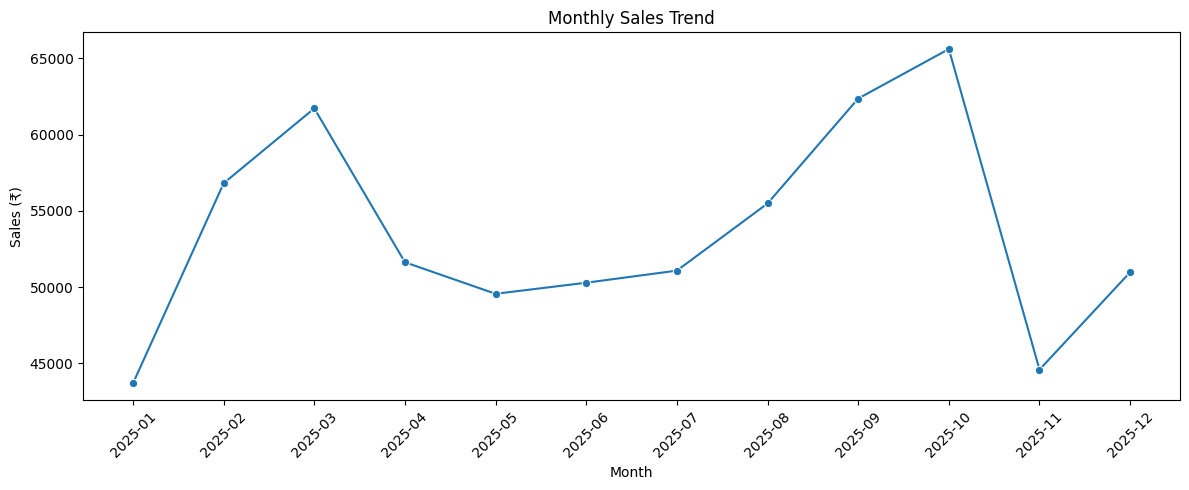

In [8]:
monthly_sales = (
    df.groupby(df["Date"].dt.to_period("M"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Date"] = monthly_sales["Date"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="Date", y="Sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


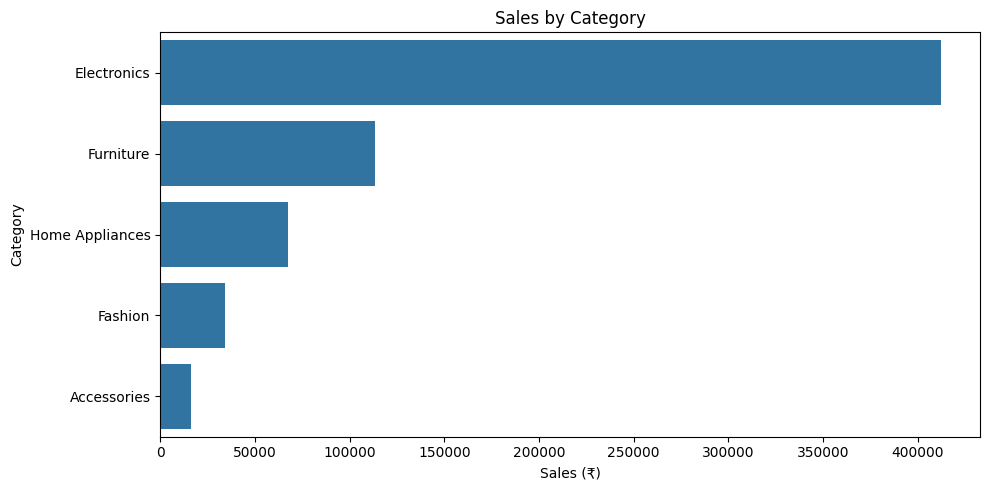

,Total_Sales
Category,
Electronics,412230.59
Furniture,113503.82
Home Appliances,67333.50
Fashion,34220.78
Accessories,16447.76


In [9]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=category_sales.values, y=category_sales.index)
plt.title("Sales by Category")
plt.xlabel("Sales (₹)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

display(category_sales.to_frame("Total_Sales"))


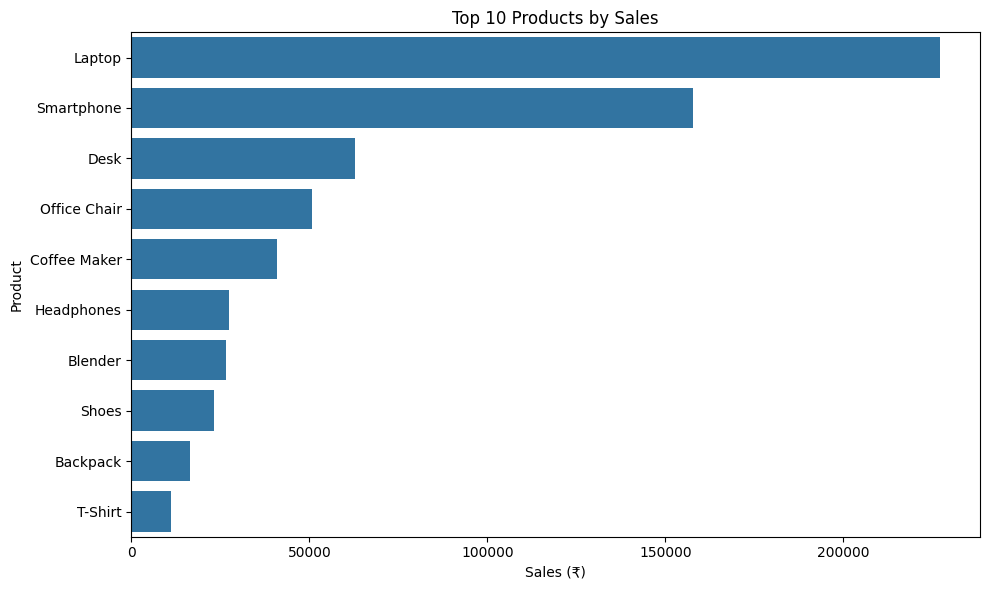

,Total_Sales
Product,
Laptop,226989.37
Smartphone,157862.79
Desk,62825.03
Office Chair,50678.79
Coffee Maker,40773.66
Headphones,27378.43
Blender,26559.84
Shoes,23184.52
Backpack,16447.76


In [10]:
top_products = (
    df.groupby("Product")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales (₹)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

display(top_products.to_frame("Total_Sales"))


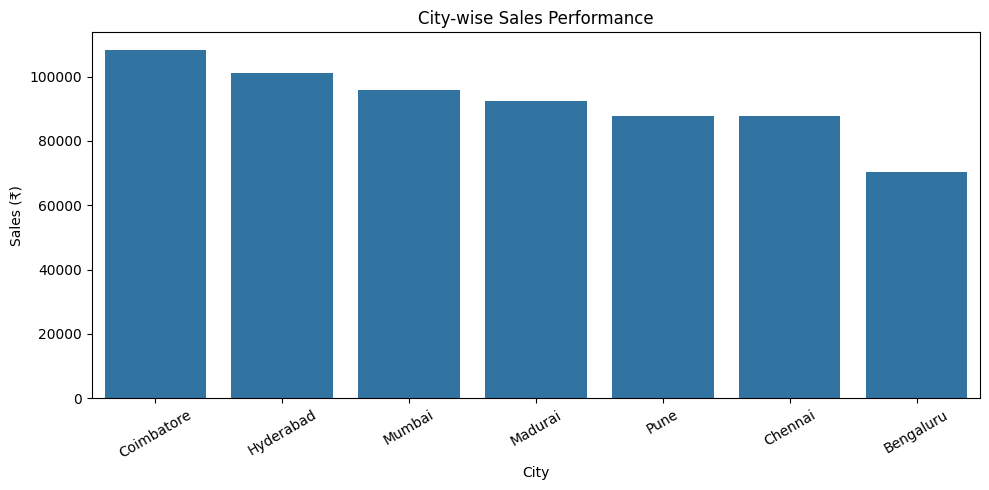

,Total_Sales
City,
Coimbatore,108388.06
Hyderabad,101135.18
Mumbai,95798.55
Madurai,92464.73
Pune,87858.82
Chennai,87851.79
Bengaluru,70239.32


In [11]:
city_sales = (
    df.groupby("City")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=city_sales.index, y=city_sales.values)
plt.title("City-wise Sales Performance")
plt.xlabel("City")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

display(city_sales.to_frame("Total_Sales"))


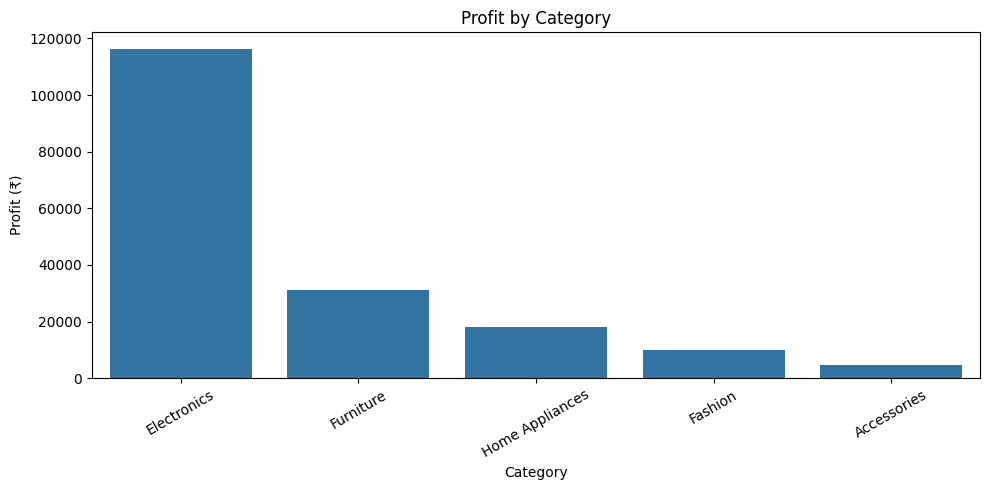

In [12]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=category_profit.index, y=category_profit.values)
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit (₹)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


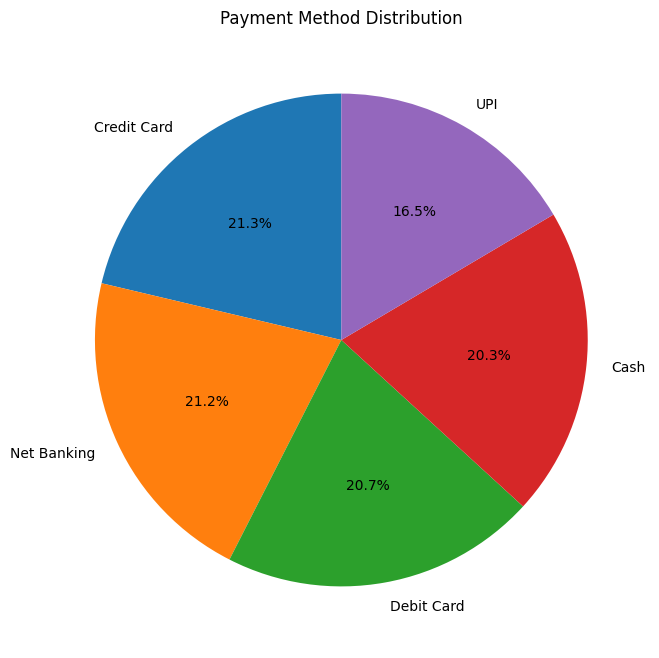

In [13]:
payment_counts = df["Payment_Method"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Payment Method Distribution")
plt.show()


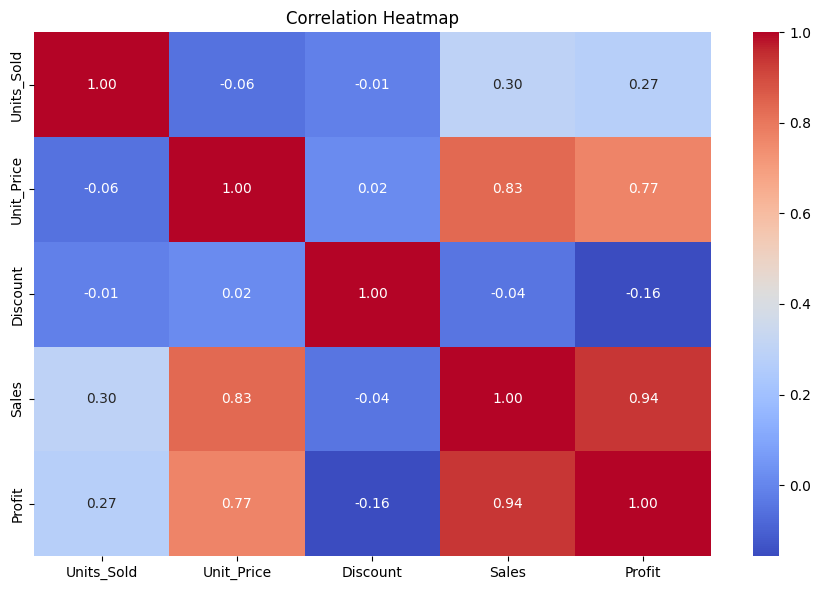

In [14]:
numeric_cols = [
    "Units_Sold", "Unit_Price", "Discount", "Sales", "Profit"
]

plt.figure(figsize=(9, 6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [15]:
best_category = category_sales.idxmax()
best_category_value = category_sales.max()

best_city = city_sales.idxmax()
best_city_value = city_sales.max()

best_product = top_products.idxmax()
best_product_value = top_products.max()

best_profit_category = category_profit.idxmax()
best_profit_value = category_profit.max()

print("🔎 KEY FINDINGS")
print("-" * 60)
print(f"1. Highest sales category: {best_category} — ₹{best_category_value:,.2f}")
print(f"2. Highest sales city: {best_city} — ₹{best_city_value:,.2f}")
print(f"3. Top product by sales: {best_product} — ₹{best_product_value:,.2f}")
print(f"4. Most profitable category: {best_profit_category} — ₹{best_profit_value:,.2f}")
print(f"5. Overall profit margin: {profit_margin:.2f}%")


🔎 KEY FINDINGS
------------------------------------------------------------
1. Highest sales category: Electronics — ₹412,230.59
2. Highest sales city: Coimbatore — ₹108,388.06
3. Top product by sales: Laptop — ₹226,989.37
4. Most profitable category: Electronics — ₹116,316.85
5. Overall profit margin: 27.97%


In [16]:
# Select features and target

features = ["Units_Sold", "Unit_Price", "Discount"]
X = df[features]
y = df["Sales"]

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


Training samples: 800
Testing samples : 200


In [17]:
# Train Random Forest Regression model

model = RandomForestRegressor(
    n_estimators=150,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")


Random Forest model trained successfully!


In [18]:
# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")


MAE  : ₹26.98
RMSE : ₹56.49
R²   : 0.9959


,Actual_Sales,Predicted_Sales
0,59.22,56.535600
1,442.56,436.356333
2,228.70,231.416267
3,147.08,149.517067
4,1735.49,1753.799000
5,865.26,978.291067
6,168.38,150.917200
7,345.42,352.879067
8,902.88,900.931133
9,519.59,528.934267


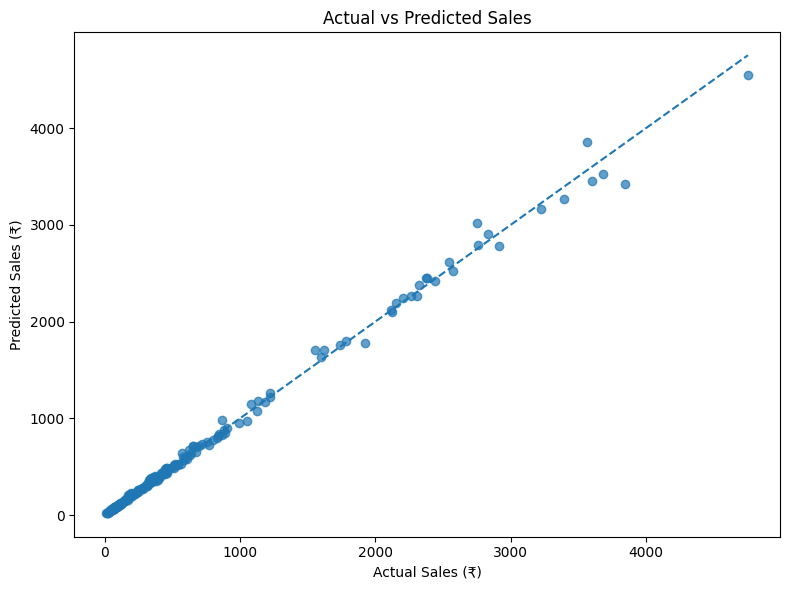

In [19]:
# Actual vs Predicted Sales

comparison = pd.DataFrame({
    "Actual_Sales": y_test.values,
    "Predicted_Sales": y_pred
})

display(comparison.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("Actual Sales (₹)")
plt.ylabel("Predicted Sales (₹)")
plt.title("Actual vs Predicted Sales")
plt.tight_layout()
plt.show()


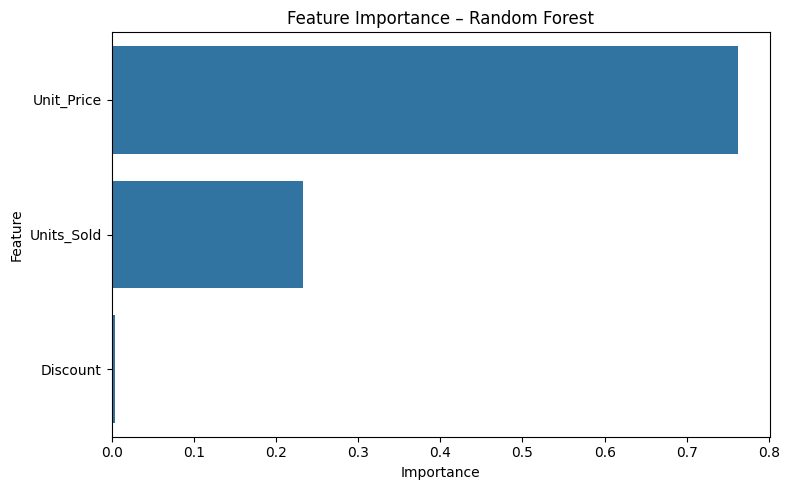

,Importance
Unit_Price,0.762815
Units_Sold,0.233162
Discount,0.004024


In [20]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance – Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(importance.to_frame("Importance"))


In [21]:
# Example prediction

units = 3
unit_price = 500
discount = 0.05

new_order = pd.DataFrame({
    "Units_Sold": [units],
    "Unit_Price": [unit_price],
    "Discount": [discount]
})

predicted_sales = model.predict(new_order)[0]

print(f"Units Sold : {units}")
print(f"Unit Price : ₹{unit_price:,.2f}")
print(f"Discount   : {discount:.0%}")
print(f"Predicted Sales: ₹{predicted_sales:,.2f}")


Units Sold : 3
Unit Price : ₹500.00
Discount   : 5%
Predicted Sales: ₹1,532.53
